In [72]:
import numpy as np
import scipy as sp
from scipy.fft import fft, fftfreq, ifft
import matplotlib.pyplot as plt
from tqdm import trange
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian

rng = np.random.default_rng()

In [2]:
class BrunelModelA():
    def __init__(self, N, Next, g, J, Ce, D, vthr_ratio):
        self.N = int(N)
        self.Ne = int(0.8*N) # excitatory neurons
        self.Ni = int(0.2*N) # inhibitory neurons
        self.Next = Next # external input neurons
        
        self.Je = J # excitatory connection strength
        self.g = g
        self.Ji = - g * J # inhibitory connection strength
        
        self.Ce = Ce # nb of excitatory connections to a single neuron
        self.Ci = int(0.25 * Ce) # nb of inhibitory connections to a single neuron
        
        self.D = D # transmission delay of spikes
        self.refractory_period = 2e-3 # duration of the refractory period after spiking
        self.Vr = 10. # resting potential value in mV
        self.Vth = 20. # spiking threshold in mV
        self.te = 20e-3 # Time constant of excitatory neurons, from Brunel
        self.vthr = self.compute_vthr() # external firing rate threshold vthr = (Vth-Vr)/(Je*Ce*te)
        self.vext = vthr_ratio * self.vthr # external excitatory neurons firing rate 

        # Boolean for network-wide connectivity matrix initialization (used for inheritance)
        self.init_W()
        # Reset potentials and spikes
        self.reset()

    # Define the network-wide connectivity matrix W
    def init_W(self):
        self.W = np.zeros((self.N, self.N + self.Next))
        for i in range(self.N):
            Ne_idxs = rng.choice(self.Ne, self.Ce, replace=False)
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i, Ne_idxs] = self.Je
            self.W[i, Ni_idxs] = self.Ji
            self.W[i, Next_idxs] = self.Je
    
    def reset(self):
        self.V = np.full((1, self.N), self.Vr, dtype='float64') # all neurons are initiated at resting potential Vr
        self.spikes = np.zeros((1, self.N))
        self.spike_count = np.array(0)
        self.refractory_times = np.full(self.N, -1., dtype='float64') # array that holds the refractory periods as the elapsed time since last spike
    
    def compute_step(self, step, exc_duration):
        # Internal spiking activity at time t - D
        delay = int(self.D//self.dt)
        if(delay + 1 > self.spikes.shape[0]):
            network_spikes = np.zeros(self.N)
        else:
            network_spikes = self.spikes[- 1 - delay]
        # External spiking excitation
        if(self.dt * step < exc_duration):
            external_spikes = rng.poisson(self.vext, self.Next)
        else: external_spikes = np.zeros(self.Next)
        #external_spikes = np.random.choice([0, 1], p=[1 - self.dt*self.vext, self.dt*self.vext], size = self.Next)
        # Total input
        spikes = np.concatenate([network_spikes, external_spikes])
        # Potential update (see Brunel, eq. 1)
        new_V = self.V[-1] + self.dt * (- (self.V[-1] - self.Vr) / self.te + np.matvec(self.W, spikes))
        # Neurons in refractory period remain unchanged
        new_V[self.refractory_times >= 0] = self.Vr # Reset to resting potential
        self.refractory_times[self.refractory_times >= 0] += self.dt # Update the time since last spike
        self.refractory_times[self.refractory_times > self.refractory_period] = -1 # Ready to spike
        # Compute the spikes
        new_spikes = np.where(new_V > self.Vth, 1, 0)
        # Update the new refractory neurons
        self.refractory_times[new_spikes == 1] = 0 # Start refractory period
        self.V = np.concatenate([self.V, [new_V]])
        self.spikes = np.concatenate([self.spikes, [new_spikes]])

    def simulate(self, T, dt, exc_duration):
        self.reset()
        n_steps = int(T//dt)
        self.T = T
        self.dt = dt
        self.n_steps = n_steps
        for i in trange(n_steps, desc="Computing potential dynamics step"):
            self.compute_step(i, exc_duration)
        self.compute_spike_count()
        self.compute_activity()

    def compute_vthr(self):
        vthr = (self.Vth - self.Vr) / (self.Je * self.Ce * self.te)
        return vthr
    
    def compute_spike_count(self):
        self.spike_count = np.sum(self.spikes, axis = 1)
    
    def compute_activity(self):
        self.activity = self.spike_count / (self.N * self.dt)
    
    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

    def plot_activity(self):
        plt.plot(self.dt * np.arange(self.activity.shape[0]), self.activity)
        plt.xlabel('Time in s')
        plt.ylabel('Activity (Hz)')

    def plot_W(self):
        plt.imshow(self.W)

Computing potential dynamics step: 100%|█████████████████████████████████████████████| 999/999 [00:15<00:00, 62.54it/s]


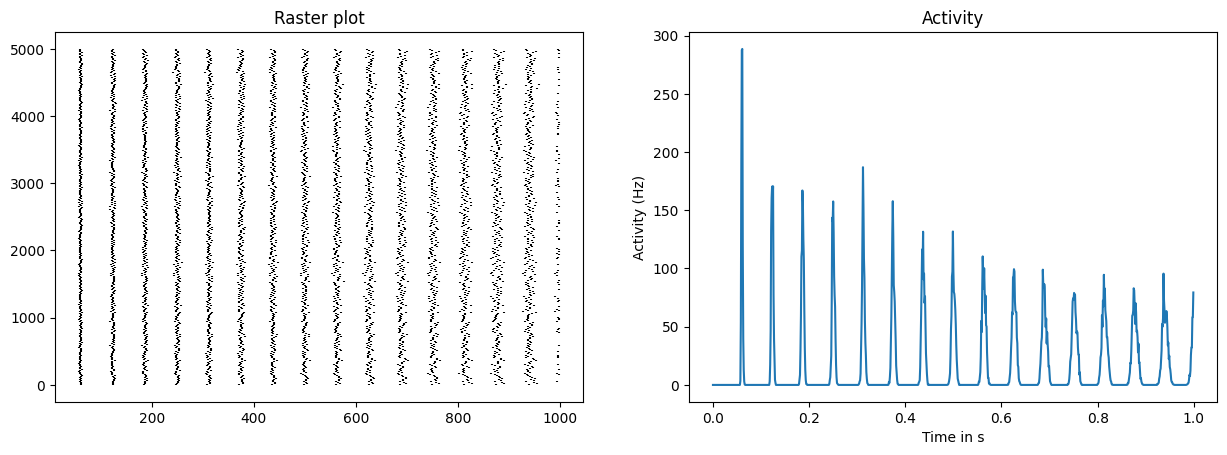

In [87]:
model = BrunelModelA(N=5000, Next=400, g=6, J=0.2, Ce=40, D=1.8e-3, vthr_ratio=1.05)
model.simulate(T=1, dt=1e-4, exc_duration=3)

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(15)
plt.sca(axs[0])
model.plot_raster()
plt.title('Raster plot')
plt.sca(axs[1])
model.plot_activity()
plt.title('Activity')
plt.show()

In [81]:
class ConnectedClusters(BrunelModelA):
    def __init__(self, N1, N2, Next, g, J, Ce, D, vthr_ratio):
        self.N1 = N1
        self.N2 = N2
        Ni = int(0.25*(N1+N2))
        super().__init__(N1+N2+Ni, Next, g, J, Ce, D, vthr_ratio)

    # Define the network-wide connectivity matrix W
    def init_W(self):
        self.W = np.zeros((self.N, self.N + self.Next))
        # Cluster 1
        for i in range(self.N1):
            N1_idxs = rng.choice(self.N1, self.Ce, replace=False)
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i, N1_idxs] = self.Je # intern to cluster 1
            self.W[i, Ni_idxs] = self.Ji # basket cells
            self.W[i, Next_idxs] = self.Je # external input
        # Cluster 2
        for i in range(self.N2):
            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i + self.N1, N2_idxs] = self.Je # intern to cluster 2
            self.W[i + self.N1, Ni_idxs] = self.Ji # basket cells
            self.W[i + self.N1, Next_idxs] = 0.85 * self.Je # external input
        # Basket cells
        for i in range(self.Ni):
            #ratio = np.random.rand()
            #n = int(ratio*self.Ce)
            #N1_idxs = rng.choice(self.N1, int(0.2*self.Ce), replace=False)
            #N2_idxs = rng.choice(self.N2, int(0.2*self.Ce), replace=False) + self.N1
            N1_idxs = rng.choice(self.N1, int(0.5*self.Ce), replace=False)
            N2_idxs = rng.choice(self.N2, int(0.5*self.Ce), replace=False) + self.N1
            self.W[i + self.Ne, N1_idxs] = self.Je # from cluster 1
            self.W[i + self.Ne, N2_idxs] = self.Je # from cluster 2

    def compute_spike_count(self):
        self.spike_count = np.empty((3, self.spikes.shape[0]))
        self.spike_count[0] = np.sum(self.spikes[:, :self.N1], axis = 1)
        self.spike_count[1] = np.sum(self.spikes[:, self.N1:self.Ne], axis = 1)
        self.spike_count[2] = np.sum(self.spikes[:, self.Ne:self.N], axis = 1)
    
    def compute_activity(self):
        self.activity = np.empty((3, self.n_steps))
        self.activity[0] = self.spike_count[0][:self.n_steps] / (self.N1 * self.dt)
        self.activity[1] = self.spike_count[1][:self.n_steps] / (self.N2 * self.dt)
        self.activity[2] = self.spike_count[2][:self.n_steps] / (self.Ni * self.dt)
    
    def plot_activity(self):
        for activity, name in zip(self.activity, ["Cluster 1", "Cluster 2", "Basket cells"]):
            plt.plot(self.dt * np.arange(activity.shape[0]), activity, label=name)
        plt.xlabel('Time in s')
        plt.ylabel('Activity (Hz)')
        plt.legend()
    
    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        colors = np.concatenate([np.full(self.N1, 'b'), np.full(self.N2, 'k'), np.full(self.Ni, 'r')])
        plt.eventplot(event, colors=colors, zorder = 0)

    def plot_STFFT(self, win_width:int):
        # Based on Scipy documentation
        # https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.html#scipy.signal.ShortTimeFFT
        T, N = self.dt, int(self.T / self.dt)  # 1000 Hz sampling rate for 1 s signal
        #t_x = np.arange(N) * T  # time indexes for signal
        
        g_std = 8  # standard deviation for Gaussian window in samples
        w = gaussian(win_width, std=g_std, sym=True)  # symmetric Gaussian window
        #SFT = ShortTimeFFT(w, hop=5, fs=1/T, mfft=200, scale_to='magnitude')
        SFT = ShortTimeFFT(w, hop=5, fs=200, mfft=200, scale_to='magnitude')
        
        fig1, axs = plt.subplots(1, 3, figsize=(18., 4.))  # enlarge plot a bit
    
        for ax1, activity, name in zip(axs, self.activity, ["Cluster 1", "Cluster 2", "Basket cells"]):
            Sx = SFT.stft(activity)  # perform the STFT
            t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
            ax1.set_title(name)
            ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                           rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                           rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                    xlim=(t_lo, t_hi))
            
            im1 = ax1.imshow(abs(Sx), origin='lower', aspect='auto',
                             extent=SFT.extent(N), cmap='viridis')
            fig1.colorbar(im1, label="Magnitude $|S_x(t, f)|$")
            
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                             (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)
        fig1.tight_layout()
        plt.show()

In [82]:
model2 = ConnectedClusters(N1=2000, N2=2000, Next=1000, g=5, J=400, Ce=80, D=2e-3, vthr_ratio=1.3)

Computing potential dynamics step: 100%|███████████████████████████████████████████| 4999/4999 [03:49<00:00, 21.80it/s]


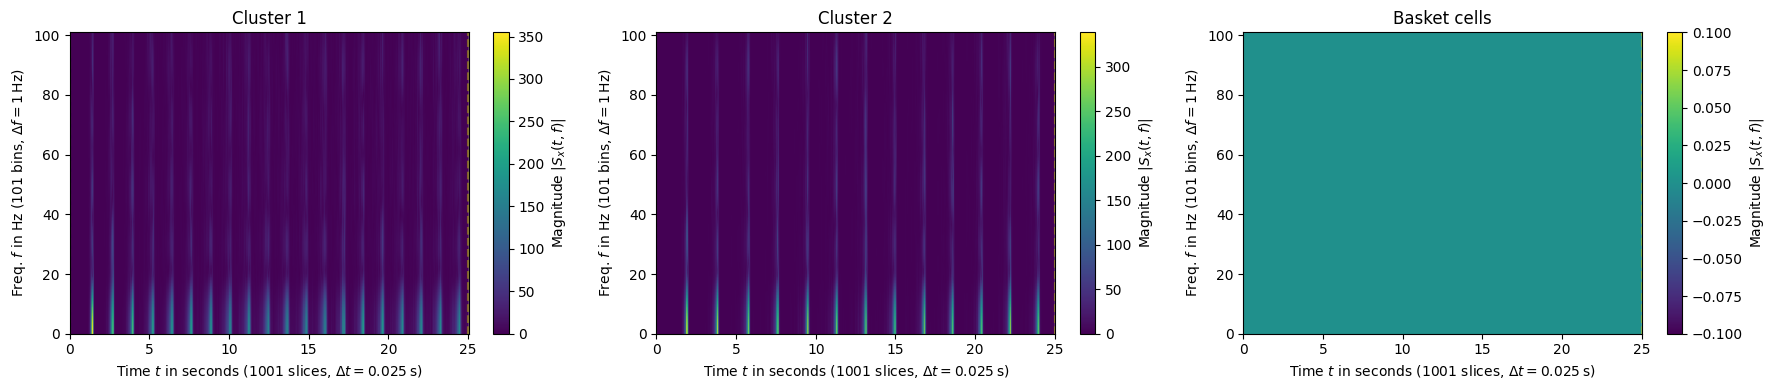

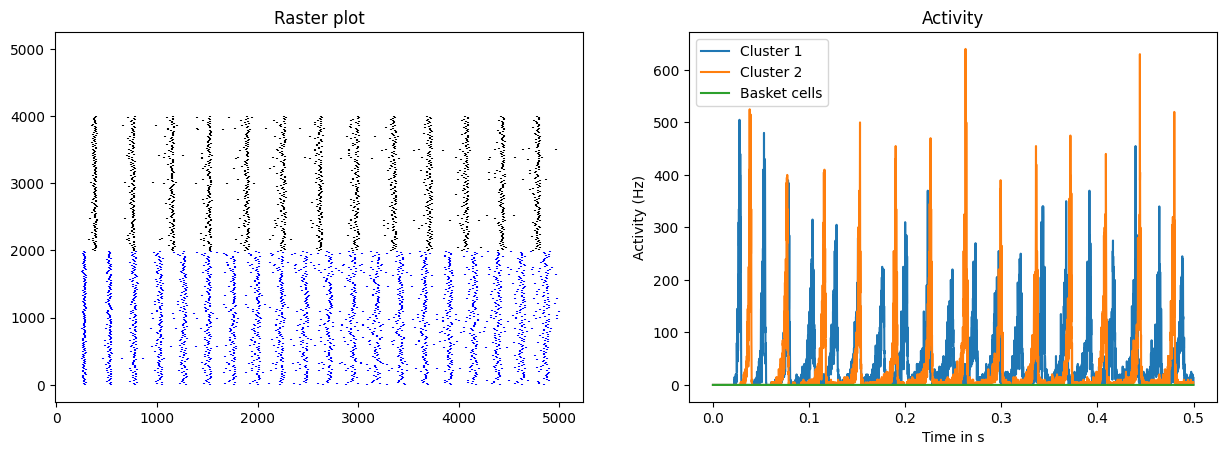

In [83]:
model2.simulate(T=0.5, dt=1e-4, exc_duration=0.5)

model2.plot_STFFT(win_width=10)

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(15)
plt.sca(axs[0])
model2.plot_raster()
plt.title('Raster plot')
plt.sca(axs[1])
model2.plot_activity()
plt.title('Activity')
plt.show()

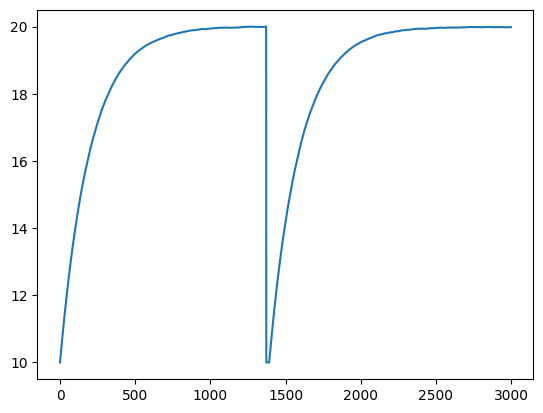

In [85]:
plt.plot(model.V[:, 4500])